# Unsupervised baseline: PCA → k-means

**Data:** `food_nutrient_conc.csv` in the parent folder (`StatLearning_FinalProject/`), one row per food.

**CLI (exports PNG + CSV):** from this folder run:

`python unsupervised_pca_kmeans.py`

Artifacts go to `unsupervised_learning/outputs/`.

**Notebook:** imports resolve whether your Jupyter working directory is `StatLearning_FinalProject` or `unsupervised_learning`.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve sibling folder whether Jupyter cwd is repo root or unsupervised_learning/
_cwd = Path.cwd().resolve()
for _p in (_cwd, _cwd / "unsupervised_learning"):
    if (_p / "unsupervised_pca_kmeans.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise ImportError(
        "Place cwd at StatLearning_FinalProject or unsupervised_learning "
        "so unsupervised_pca_kmeans.py can be imported."
    )

from unsupervised_pca_kmeans import (
    DEFAULT_K_CLUSTERS,
    DEFAULT_N_COMPONENTS_KMEANS,
    PROJECT_ROOT,
    SCREE_PLOT_COMPONENTS,
    fit_pca_kmeans,
    load_feature_matrix,
)

In [2]:
DATA_PATH = PROJECT_ROOT / "food_nutrient_conc.csv"

K = DEFAULT_K_CLUSTERS
PC_FOR_KMEANS = DEFAULT_N_COMPONENTS_KMEANS
RANDOM_SEED = 42

assert DATA_PATH.is_file(), f"Missing data file: {DATA_PATH}"

In [3]:
X_raw, food_names = load_feature_matrix(DATA_PATH)
print(f"Foods: {len(X_raw):,} | Nutrient features: {X_raw.shape[1]}")
X_raw.head()

Foods: 5,431 | Nutrient features: 65


,"Calcium, Ca",Retinol,Lycopene,MUFA 20:1,PUFA 20:5 n-3 (EPA),SFA 14:0,Total Sugars,"Carotene, beta",Total lipid (fat),Thiamin,...,"Selenium, Se","Vitamin A, RAE","Vitamin E, added","Folate, total","Sodium, Na","Vitamin C, total ascorbic acid",Theobromine,SFA 18:0,MUFA 18:1,SFA 4:0
0,125,57,0,0.002,0.000,0.204,4.88,4,2.14,0.057,...,1.9,58,0.0,1,39,0.1,0,0.208,0.465,0.046
1,123,31,0,0.004,0.001,0.303,4.81,7,3.20,0.056,...,1.9,32,0.0,0,38,0.0,0,0.309,0.694,0.067
2,126,83,0,0.002,0.000,0.181,4.89,3,1.90,0.059,...,1.8,83,0.0,2,39,0.2,0,0.184,0.410,0.041
3,126,58,0,0.001,0.000,0.093,4.96,1,0.95,0.057,...,2.1,58,0.0,2,39,0.0,0,0.096,0.214,0.022
4,132,64,0,0.000,0.000,0.008,5.05,2,0.08,0.056,...,2.0,64,0.0,2,41,0.0,0,0.009,0.018,0.003


In [4]:
result = fit_pca_kmeans(
    X_raw,
    food_names,
    k=K,
    pc_kmeans=PC_FOR_KMEANS,
    seed=RANDOM_SEED,
)

evr = result.pca.explained_variance_ratio_
cum = np.cumsum(evr)
print(f"K-means: K={K}, PCs used for clustering={result.n_pc_kmeans}")
print(f"Inertia: {result.kmeans.inertia_:,.2f} | Silhouette: {result.silhouette:.4f}")
print(
    f"Variance: PC1={evr[0]*100:.2f}% | PC2={evr[1]*100:.2f}% | "
    f"Cumulative (first {result.n_pc_kmeans} PCs)={cum[result.n_pc_kmeans - 1]*100:.2f}%"
)

K-means: K=8, PCs used for clustering=15
Inertia: 141,289.84 | Silhouette: 0.2885
Variance: PC1=15.90% | PC2=10.59% | Cumulative (first 15 PCs)=73.49%


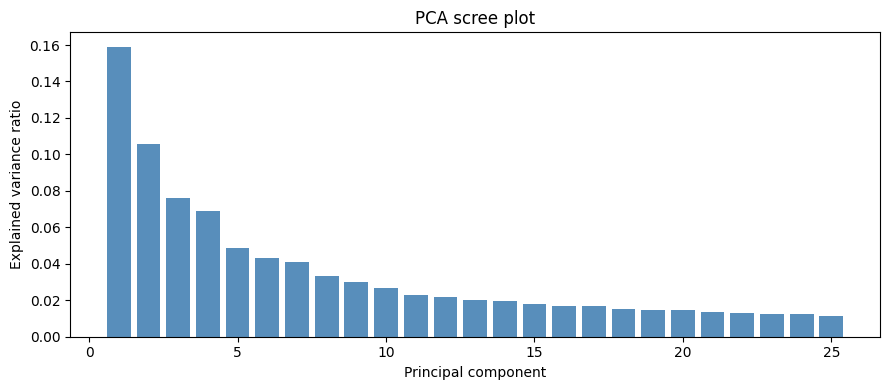

In [5]:
n_scree = min(SCREE_PLOT_COMPONENTS, len(evr))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(1, n_scree + 1), evr[:n_scree], color="steelblue", alpha=0.9)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree plot")
fig.tight_layout()

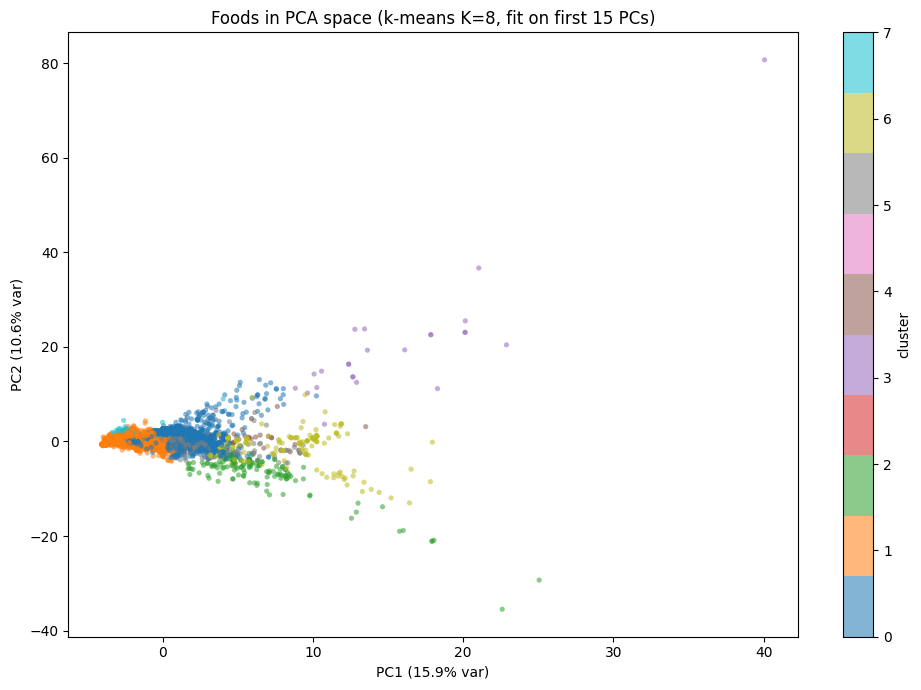

In [6]:
Z = result.Z
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    c=result.cluster_labels,
    cmap="tab10",
    alpha=0.55,
    s=14,
    linewidths=0,
)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
ax.set_title(
    f"Foods in PCA space (k-means K={K}, fit on first {result.n_pc_kmeans} PCs)"
)
plt.colorbar(sc, ax=ax, label="cluster")
fig.tight_layout()

In [7]:
assignments = pd.DataFrame(
    {
        "Food_Name": result.food_names.values,
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "cluster": result.cluster_labels,
    }
)
assignments.groupby("cluster")["Food_Name"].count().rename("n_foods")

cluster
0    1121
1    2712
2     145
3      24
4      51
5    1146
6     158
7      74
Name: n_foods, dtype: int64

In [8]:
assignments.sort_values("PC1").tail(8)

,Food_Name,PC1,PC2,cluster
5349,"Nutritional powder mix, high protein (Herbalife)",20.123741,23.079032,3
5357,"Nutritional powder mix, high protein, NFS",20.123741,23.079032,3
5355,"Nutritional powder mix, high protein (Slim Fast)",20.138064,25.509632,3
4621,Yeast,21.035635,36.694612,3
4798,Coconut oil,22.595029,-35.474564,2
769,"Liver, beef",22.875772,20.434713,3
4784,"Ghee, clarified butter",25.055158,-29.323750,2
4622,Yeast extract spread,40.053115,80.714033,3
